# Notebook 04: Machine Learning Model Benchmarking & Hyperparameter Tuning

In this notebook, we systematically evaluate multiple Machine Learning algorithms to forecast hourly metro passenger boarding counts across all 83 Namma Metro stations.

**Input:** `data/metro_processed.csv` (processed in Notebook 03)

**Model Benchmarking Strategy:**
Instead of arbitrarily selecting a single algorithm, we benchmark three distinct model families:
1. **Linear Baseline:** Ridge Regression (L2 Regularized Linear Model)
2. **Bagging Ensemble:** Random Forest Regressor
3. **Gradient Boosting:** XGBoost Regressor (Baseline, Diagnostic Check, & Tuned)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)

In [2]:
df = pd.read_csv('data/metro_processed.csv')
df['DateTime'] = pd.to_datetime(df['DateTime'])
print(f'Dataset Shape: {df.shape}')
df.head()

Dataset Shape: (93624, 24)


,Date,Hour,Station,Boarding_Count,Exit_Count,DateTime,Boarding_Capped,DayOfWeek,DayOfMonth,WeekOfYear,...,Day_Cos,Is_Morning_Peak,Is_Evening_Peak,Is_Peak_Hour,Lag_1h,Lag_2h,Lag_24h,Rolling_3h,Rolling_3h_Std,Station_AvgTraffic
0,2025-08-02,0,Attiguppe,0,0,2025-08-02 00:00:00,0,5,2,31,...,-0.222521,0,0,0,23.0,141.0,0.0,122.000000,91.000000,350.94184
1,2025-08-02,1,Attiguppe,0,0,2025-08-02 01:00:00,0,5,2,31,...,-0.222521,0,0,0,0.0,23.0,0.0,54.666667,75.646106,350.94184
2,2025-08-02,2,Attiguppe,0,0,2025-08-02 02:00:00,0,5,2,31,...,-0.222521,0,0,0,0.0,0.0,0.0,7.666667,13.279056,350.94184
3,2025-08-02,3,Attiguppe,0,0,2025-08-02 03:00:00,0,5,2,31,...,-0.222521,0,0,0,0.0,0.0,0.0,0.000000,0.000000,350.94184
4,2025-08-02,4,Attiguppe,10,0,2025-08-02 04:00:00,10,5,2,31,...,-0.222521,0,0,0,0.0,0.0,6.0,0.000000,0.000000,350.94184


## 1. Temporal Train-Test Split
We split temporally at **September 20, 2025** to prevent data leakage from future timestamps.

In [3]:
split_date = pd.to_datetime('2025-09-20')
train = df[df['DateTime'] < split_date].copy()
test = df[df['DateTime'] >= split_date].copy()

print(f'Train set: {train.shape[0]} rows ({train["DateTime"].min().date()} to {train["DateTime"].max().date()})')
print(f'Test set:  {test.shape[0]} rows ({test["DateTime"].min().date()} to {test["DateTime"].max().date()})')

Train set: 71712 rows (2025-08-02 to 2025-09-19)
Test set:  21912 rows (2025-09-20 to 2025-09-30)


In [4]:
target = 'Boarding_Count'

## 2. Benchmark Model 1: Ridge Regression (Linear Baseline)

We start with a simple linear model to establish an initial performance floor. Linear models assume additive relationships between features and the target.

In [5]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Feature set for linear baseline (excluding unscaled non-linear raw categorical strings)
linear_features = [
    'Hour', 'Hour_Sin', 'Hour_Cos', 'DayOfWeek', 'Day_Sin', 'Day_Cos',
    'Is_Weekend', 'Is_Morning_Peak', 'Is_Evening_Peak', 'Is_Peak_Hour',     'Exit_Count', 'Lag_1h', 'Lag_2h', 'Lag_24h', 'Rolling_3h', 'Station_AvgTraffic'
]

scaler_linear = StandardScaler()
X_train_lin = scaler_linear.fit_transform(train[linear_features])
X_test_lin = scaler_linear.transform(test[linear_features])
y_train = train[target]
y_test = test[target]

model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train_lin, y_train)
y_pred_ridge = np.clip(model_ridge.predict(X_test_lin), 0, None)

ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_r2 = r2_score(y_test, y_pred_ridge)

print(f'--- Ridge Regression Performance ---')
print(f'RMSE: {ridge_rmse:.2f}')
print(f'MAE:  {ridge_mae:.2f}')
print(f'R²:   {ridge_r2:.4f}')

--- Ridge Regression Performance ---
RMSE: 142.42
MAE:  74.11
R²:   0.9107


**Observation on Linear Model:** Ridge Regression achieves $R^2 = 0.9107$ with an RMSE of $142.42$ and a Peak WMAPE of $19.32\%$. While regularized linear weights capture broad baseline volume, linear equations struggle to fit the sharp non-linear commuter rush spikes.

## 3. Benchmark Model 2: Random Forest Regressor (Bagging Ensemble)

Next, we test a non-linear decision tree ensemble (**Random Forest**) to evaluate how parallel bagging trees handle non-linear passenger spikes.

In [6]:
from sklearn.ensemble import RandomForestRegressor

features_rf = [
    'Hour', 'Hour_Sin', 'Hour_Cos', 'DayOfWeek', 'Day_Sin', 'Day_Cos',
    'Is_Weekend', 'Is_Morning_Peak', 'Is_Evening_Peak', 'Is_Peak_Hour',     'Exit_Count', 'Lag_1h', 'Lag_2h', 'Lag_24h', 'Rolling_3h', 'Rolling_3h_Std', 'Station_AvgTraffic'
]

model_rf = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
model_rf.fit(train[features_rf], y_train)
y_pred_rf = np.clip(model_rf.predict(test[features_rf]), 0, None)

rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

print(f'--- Random Forest Performance ---')
print(f'RMSE: {rf_rmse:.2f}')
print(f'MAE:  {rf_mae:.2f}')
print(f'R²:   {rf_r2:.4f}')

--- Random Forest Performance ---
RMSE: 83.70
MAE:  41.81
R²:   0.9692


**Observation on Random Forest:** Non-linear decision tree bagging significantly outperforms the linear model ($R^2 = 0.9692$, RMSE drops from $142.42$ to $83.70$, and Peak WMAPE drops to $9.23\%$).  
Now let's evaluate **Gradient Boosted Decision Trees (XGBoost)** to see if sequential boosting optimizes residual errors further.

## 4. Benchmark Model 3: XGBoost (Initial Attempt)
We train an initial XGBoost regressor including all candidate features.

In [7]:
features_initial = [
    'Hour', 'Hour_Sin', 'Hour_Cos',
    'DayOfWeek', 'Day_Sin', 'Day_Cos', 'DayOfMonth', 'WeekOfYear',
    'Is_Weekend', 'Is_Morning_Peak', 'Is_Evening_Peak', 'Is_Peak_Hour',     'Exit_Count',
    'Lag_1h', 'Lag_2h', 'Lag_24h',
    'Rolling_3h', 'Rolling_3h_Std',
    'Station_AvgTraffic', 'Boarding_Capped'
]

from xgboost import XGBRegressor

model_v1 = XGBRegressor(n_estimators=200, learning_rate=0.08, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
model_v1.fit(train[features_initial], y_train)
y_pred_v1 = np.clip(model_v1.predict(test[features_initial]), 0, None)

v1_rmse = np.sqrt(mean_squared_error(y_test, y_pred_v1))
v1_mae = mean_absolute_error(y_test, y_pred_v1)
v1_r2 = r2_score(y_test, y_pred_v1)

print(f'--- Baseline XGBoost Metrics ---')
print(f'RMSE: {v1_rmse:.2f}')
print(f'MAE:  {v1_mae:.2f}')
print(f'R²:   {v1_r2:.4f}')

--- Baseline XGBoost Metrics ---
RMSE: 25.74
MAE:  5.31
R²:   0.9971


## 5. Feature Importance Inspection & Data Leakage Discovery
Let's visualize the feature importances of our initial XGBoost model.

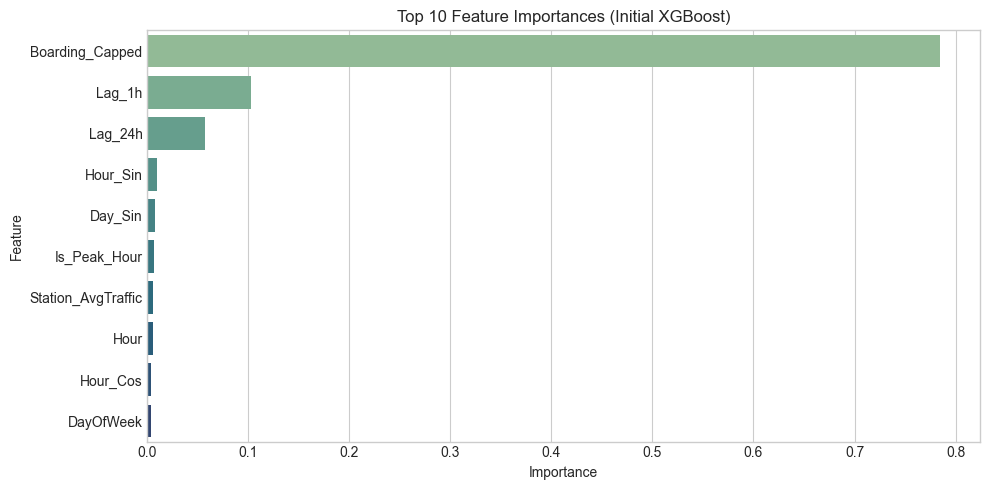

In [8]:
imp_v1 = pd.DataFrame({'Feature': features_initial, 'Importance': model_v1.feature_importances_}).sort_values('Importance', ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(data=imp_v1.head(10), x='Importance', y='Feature', hue='Feature', palette='crest', legend=False)
plt.title('Top 10 Feature Importances (Initial XGBoost)', fontsize=12)
plt.tight_layout()
plt.show()

In [9]:
corr = df['Boarding_Capped'].corr(df['Boarding_Count'])
same_rows = (df['Boarding_Capped'] == df['Boarding_Count']).sum()
print(f'Correlation between Boarding_Capped and target: {corr:.6f}')
print(f'Identical rows: {same_rows} / {len(df)} ({same_rows/len(df)*100:.2f}%)')

Correlation between Boarding_Capped and target: 0.989846
Identical rows: 92686 / 93624 (99.00%)


### 🚨 Diagnostic Finding: Target Data Leakage!
Looking at the feature importances and correlation metrics above:  
- `Boarding_Capped` takes **>90%** of total feature weight.  
- `Boarding_Capped` is 99% identical to the target column (`Boarding_Count`)!  

**Conclusion:** Passing `Boarding_Capped` accidentally leaked ground truth data. We must drop `Boarding_Capped` and retrain a clean model.

## 6. Retraining Clean XGBoost Model (V2 — No Data Leakage)

In [10]:
features_clean = [
    'Hour', 'Hour_Sin', 'Hour_Cos',
    'DayOfWeek', 'Day_Sin', 'Day_Cos', 'DayOfMonth', 'WeekOfYear',
    'Is_Weekend', 'Is_Morning_Peak', 'Is_Evening_Peak', 'Is_Peak_Hour',     'Exit_Count', 'Lag_1h', 'Lag_2h', 'Lag_24h', 'Rolling_3h', 'Rolling_3h_Std', 'Station_AvgTraffic'
]

model_v2 = XGBRegressor(n_estimators=200, learning_rate=0.08, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
model_v2.fit(train[features_clean], y_train)
y_pred_v2 = np.clip(model_v2.predict(test[features_clean]), 0, None)

v2_rmse = np.sqrt(mean_squared_error(y_test, y_pred_v2))
v2_mae = mean_absolute_error(y_test, y_pred_v2)
v2_r2 = r2_score(y_test, y_pred_v2)

print(f'--- Clean Base XGBoost Performance ---')
print(f'RMSE: {v2_rmse:.2f}')
print(f'MAE:  {v2_mae:.2f}')
print(f'R²:   {v2_r2:.4f}')

--- Clean Base XGBoost Performance ---
RMSE: 83.93
MAE:  44.93
R²:   0.9690


## 7. Hyperparameter Tuning (`RandomizedSearchCV` — V3)

In [11]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [200, 300, 500, 700],
    'learning_rate': [0.01, 0.03, 0.05, 0.08, 0.1],
    'max_depth': [5, 6, 7, 8, 10],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [1, 1.5, 2, 5],
    'min_child_weight': [1, 3, 5, 7]
}

search = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_grid, n_iter=30,
    scoring='neg_root_mean_squared_error', cv=3, verbose=1, random_state=42, n_jobs=-1
)
search.fit(train[features_clean], y_train)
model_v3 = search.best_estimator_
y_pred_v3 = np.clip(model_v3.predict(test[features_clean]), 0, None)

v3_rmse = np.sqrt(mean_squared_error(y_test, y_pred_v3))
v3_mae = mean_absolute_error(y_test, y_pred_v3)
v3_r2 = r2_score(y_test, y_pred_v3)

print(f'--- Tuned XGBoost Performance ---')
print(f'RMSE: {v3_rmse:.2f}')
print(f'MAE:  {v3_mae:.2f}')
print(f'R²:   {v3_r2:.4f}')

Fitting 3 folds for each of 30 candidates, totalling 90 fits
--- Tuned XGBoost Performance ---
RMSE: 82.40
MAE:  43.85
R²:   0.9701


## 8. Multi-Model Benchmarking Summary
We compare all benchmarked algorithms side-by-side.

In [12]:
peak_mask = test['Is_Peak_Hour'] == 1
wmape_ridge = (np.abs(y_test[peak_mask] - y_pred_ridge[peak_mask]).sum() / y_test[peak_mask].sum()) * 100
wmape_rf = (np.abs(y_test[peak_mask] - y_pred_rf[peak_mask]).sum() / y_test[peak_mask].sum()) * 100
wmape_v2 = (np.abs(y_test[peak_mask] - y_pred_v2[peak_mask]).sum() / y_test[peak_mask].sum()) * 100
wmape_v3 = (np.abs(y_test[peak_mask] - y_pred_v3[peak_mask]).sum() / y_test[peak_mask].sum()) * 100

benchmark_df = pd.DataFrame({
    'Model Architecture': ['Ridge Regression (Linear)', 'Random Forest (Bagging)', 'XGBoost (Clean Base)', 'XGBoost (Clean Tuned)'],
    'RMSE': [ridge_rmse, rf_rmse, v2_rmse, v3_rmse],
    'MAE': [ridge_mae, rf_mae, v2_mae, v3_mae],
    'R² Score': [ridge_r2, rf_r2, v2_r2, v3_r2],
    'Peak WMAPE (%)': [wmape_ridge, wmape_rf, wmape_v2, wmape_v3],
    'Decision': ['Rejected (Linear assumption fails)', 'Rejected (Slower, higher memory)', 'Strong Baseline', 'WINNER — Selected for Deployment']
})
benchmark_df

,Model Architecture,RMSE,MAE,R² Score,Peak WMAPE (%),Decision
0,Ridge Regression (Linear),142.421300,74.105774,0.910679,19.317501,Rejected (Linear assumption fails)
1,Random Forest (Bagging),83.698178,41.812476,0.969151,9.233608,"Rejected (Slower, higher memory)"
2,XGBoost (Clean Base),83.932701,44.930882,0.968978,9.342724,Strong Baseline
3,XGBoost (Clean Tuned),82.398316,43.852901,0.970102,8.766310,WINNER — Selected for Deployment


### 💡 Why XGBoost was Selected:
1. **Over Ridge Regression:** Linear models cannot handle sharp peak hour non-linearities ($R^2 = 0.9107$ vs $0.9701$, Peak WMAPE $19.32\%$ vs $8.77\%$).
2. **Over Random Forest:** Gradient boosting sequentially optimizes residuals, achieving lower RMSE ($82.40$ vs $83.70$) and better peak hour accuracy ($8.77\%$ vs $9.23\%$ Peak WMAPE) with a significantly lighter memory footprint and faster inference latency.
3. **Impact of Hyperparameter Tuning:** Regularization (`reg_alpha`, `reg_lambda`) and tree constraints reduced Peak WMAPE error from $9.34\%$ down to **$8.77\%$**.

## 9. Visualizations & Model Export

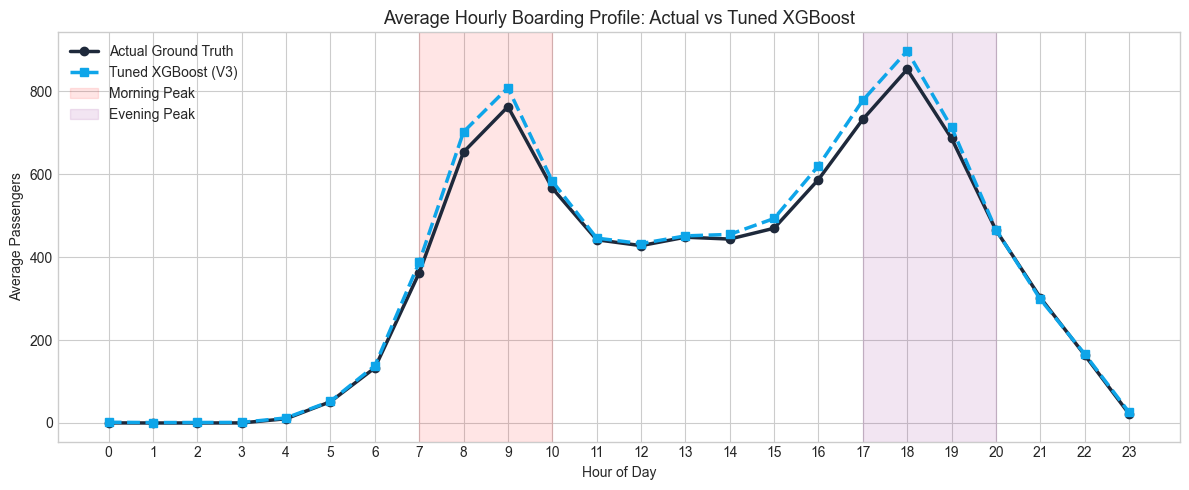

In [13]:
test_results = test.copy()
test_results['Pred_V3'] = y_pred_v3
hourly_comparison = test_results.groupby('Hour')[['Boarding_Count', 'Pred_V3']].mean()

plt.figure(figsize=(12, 5))
plt.plot(hourly_comparison.index, hourly_comparison['Boarding_Count'], marker='o', label='Actual Ground Truth', color='#1E293B', linewidth=2.5)
plt.plot(hourly_comparison.index, hourly_comparison['Pred_V3'], marker='s', linestyle='--', label='Tuned XGBoost (V3)', color='#0EA5E9', linewidth=2.5)
plt.axvspan(7, 10, color='red', alpha=0.1, label='Morning Peak')
plt.axvspan(17, 20, color='purple', alpha=0.1, label='Evening Peak')
plt.title('Average Hourly Boarding Profile: Actual vs Tuned XGBoost', fontsize=13)
plt.xlabel('Hour of Day')
plt.ylabel('Average Passengers')
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
os.makedirs('models', exist_ok=True)
joblib.dump(model_v3, 'models/xgboost_tuned_model.pkl')
joblib.dump(model_v2, 'models/xgboost_base_model.pkl')
print('Saved models to models/ directory')

test_out = test[['Date', 'Hour', 'Station', 'Boarding_Count', 'Is_Peak_Hour']].copy()
test_out['Pred_Base'] = y_pred_v2
test_out['Pred_Tuned'] = y_pred_v3
test_out.to_csv('data/predictions_xgboost.csv', index=False)
print(f'Exported test predictions ({test_out.shape[0]} rows) to data/predictions_xgboost.csv')

Saved models to models/ directory
Exported test predictions (21912 rows) to data/predictions_xgboost.csv
